
<div class="alert alert-block alert-success" style="font-family:Times New Roman;color:#FFFFFF;background-color: #E7E7E7">
<h1 align="center"><span style="font-family:Times New Roman;color:#046D0B"><b>Bioestadística para Investigación Científica <br>usando Python con Inteligencia Artificial</b></span></h1>
</div>
<style>
table tr:last-child td:last-child {
  border-bottom-right-radius: 0.5rem;
}
</style>


<table align="center" style="font-size: 13px;">
<tr>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">Autor</span></th>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">:VR ROJAS</span></th>
</tr>
<tr>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">Email</span></th>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">:sacha.analytics@gmail.com</span></th>
</tr>
<tr>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">Web</span></th>
    <th align="left">:<a href="https://sacha-analytics.github.io/" style="font-family:Monospace;font-size: 13px;">sacha-analytics</a></th>
</tr>
</table>
<br>

# 8. <b>Diseño de Caso Estudio:</b> Infecciones Respiratorias Agudas






En una era de riesgos sanitarios de enfermedades transmisibles emergentes y reemergentes, no debe subestimarse la importancia de la prevención de infecciones ni de las medidas de control en entornos sanitarios. La transmisión de enfermedad transmisible/patógeno es un tema en constante evolución, y la transmisión de patógenos que causan enfermedades respiratorias agudas (ERA) no es una excepción. El principal modo de transmisión de la mayoría de las ERA es a través de microgotas, pero en el caso de algunos patógenos la transmisión también ocurre a través del contacto (incluyendo contaminación de las manos seguida de autoinoculación) y de aerosoles respiratorios infecciosos de diversos tamaños y a corta distancia. Debido a que muchos síntomas de las ERA no son específicos y que no siempre hay pruebas diagnósticas rápidas disponibles, con frecuencia no es posible conocer la etiología de inmediato. Además, puede no haber disponibilidad de intervenciones farmacéuticas (vacunas, antivirales, antimicrobianos) para las ERA.

Las ERA están directamente vinculadas a la **calidad del aire**. Los contaminantes atmosféricos actúan como desencadenantes o agrabantes, especialmente en poblaciones vulnerables (niños, ancianos y personas con enfermedades crónicas).

**Fuentes**
* <a href="https://www.gob.pe/21263-que-son-las-infecciones-respiratorias-agudas">MINSA</a>

* <a href="https://www.who.int/es/publications/i/item/WHO-CDS-EPR-2007-6">Organización Mundial de la Salud (OMS)</a>

# **I. Marco Teórico**

## **1.1 Objetivo**

Analizar la distribución y características de casos de **infecciones respiratorias agudas** en función de las variables **departamento, defunciones** y **Tipo de Diagnóstico** utilizando métodos bioestadístico.

## **1.2 Fundamentos Bioestadisiticos**

### **1.2.1 Tipos de variables**
* **departamento**: categórica nomial (Femenino, Masculino).
* **defunciones**: cuantitativa continua.
* **Tipo de Diagnóstico (Tipo de Dx)**: categórica nominal

### **1.2.2 Métodos estadísticos relevantes**
* Estadística descriptiva univariada y bivariada
* Distribución de frecuencias.
* Medidas de tendencia central y dispersión.
* Prueba de independencia (Chi-cuadrado)
* Comparaciones de medidas (t-test, ANOVA)
* Modelos de regresión logística (para predecir DX)
* Modelos multivariantes (regresión logística si se desea modelar probabilidad de anemia)
* Validación de supuestos estadísticos

# **II. Recolección de Datos**

### **2.1. Fuentes de datos**

* <a href="https://www.datosabiertos.gob.pe">Plataforma Nacional de Datos Abiertos</a>.

* Datos para caso estudio estudio: <a href="https://www.datosabiertos.gob.pe/dataset/vigilancia-epidemiologica-de-infecciones-respiratoiras-agudas-ira">Infecciones Respiratoiras Agudas (IRA)</a>.

* Datos para caso estudio estudio: <a href="https://www.datosabiertos.gob.pe/dataset/monitoreo-de-los-contaminantes-del-aire-en-lima-metropolitana-servicio-nacional-de">Calidad del Aire Lima Metropolitana</a>.

# **III. Metodología Práctica**

## **3.1. Gestión de archivos y directorios en la Nube**

### 3.1.1. Montar Google Drive

La siguiente celda de código monta Google Drive a la nube (centro de datos remoto de Google)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 3.1.2. Explorar archivos y directorios de Google Drive desde la nube

En la siguiente celda de código se define la ruta de  **Google Drive** en la computadora en la nube

In [ ]:
drive_dir = "/content/drive/MyDrive/"

print(drive_dir)

['datos_abiertos_vigilancia_dengue_2000_2023.csv', 'datos_abiertos_vigilancia_malaria_2000_2008.csv', 'datos_abiertos_vigilancia_malaria_2009_2023.csv', 'Dataset_ExamenesLaboratorio_ConsultaExterna_PatologíasRelacionadas_Diabetes_202001_202404.csv', 'datos_abiertos_vigilancia_zoonosis_2000_2023.csv', 'datos_abiertos_vigilancia_iras_2000_2023.csv', 'datos_abiertos_vigilancia_enfermedad_carrion_2000_2023.csv', 'pmGenoma_25Septiembre2021.csv', 'pmGenoma_27Sep2023.csv', 'TB_DIGTEL_ANEMIA_TRATAMIENTOS.csv', 'primeras_100_filas_anemia.xlsx', 'primeras_100_filas_anemia.gsheet']


La funión `explorar_drive` permite inspeccionar cada carpeta y subcarpetas de **Google Drive**

In [ ]:
def explorar_drive(nombre_carpeta):
  import os
  ruta_drive ="/content/drive/MyDrive/"
  contenido_carpeta = os.listdir(ruta_drive + nombre_carpeta)
  n_elem = len(contenido_carpeta)

  print(f"Ruta: {ruta_drive + nombre_carpeta}")
  print(f"Numero de elementos: {n_elem}")

  for i in range(n_elem):
    print(f"({i}) {contenido_carpeta[i]}")

datos_abiertos_vigilancia_dengue_2000_2023.csv
datos_abiertos_vigilancia_malaria_2000_2008.csv
datos_abiertos_vigilancia_malaria_2009_2023.csv
Dataset_ExamenesLaboratorio_ConsultaExterna_PatologíasRelacionadas_Diabetes_202001_202404.csv
datos_abiertos_vigilancia_zoonosis_2000_2023.csv
datos_abiertos_vigilancia_iras_2000_2023.csv
datos_abiertos_vigilancia_enfermedad_carrion_2000_2023.csv
pmGenoma_25Septiembre2021.csv
pmGenoma_27Sep2023.csv
TB_DIGTEL_ANEMIA_TRATAMIENTOS.csv
primeras_100_filas_anemia.xlsx
primeras_100_filas_anemia.gsheet


In [ ]:
explorar_drive("Base_datos")

In [ ]:
explorar_drive("Base_datos/biomedicina")

## **3.2 Preparar Entorno**

### 3.2.1 Importar paquetes

In [ ]:
# Paquete especializado en metodos numericos
import numpy as np

# Paquete especialozado manejo de estructuras de datos tipo tablas (Data Frames)
import pandas as pd

# Paquetes especializado para generar graficas
import seaborn as sns
import matplotlib.pyplot as plt

# Paquete especializados de estadística y metodos numéricos
from scipy import stats

# Paquete especializado en estadística
import statsmodels.api as sm
import statsmodels.formula.api as smf
#from statsmodels.formula.api import ols

### 3.2.2. Explorar herramientas de Paquetes

In [ ]:
print("Lista de todos los atributos (métodos, clases, funciones):")

herramientas_paquete = dir(np)
numero_herramientas = len(herramientas_paquete)
print(f"Numero de herramientas: {numero_herramientas}")

for i in range(numero_herramientas):
  print(f"({i}) {herramientas_paquete[i]}")

Para obtener documentación detallada sobre el paquete `numpy`, puedes usar `help(np)`. Esto imprimirá una gran cantidad de información directamente en la salida de la celda. **Advertencia: Esta salida puede ser muy larga.**

In [ ]:
# Descomenta la siguiente línea para ver la documentación completa de numpy
help(np.zeros)

## **3.3. Importar Base de Datos**

In [ ]:
nombre_archivo = "datos_abiertos_vigilancia_iras_2000_2023.csv"
data_dir = "/content/drive/MyDrive/Base_datos/biomedicina/"

df = pd.read_csv(data_dir + nombre_archivo)
print(df)

        departamento    provincia     distrito   ano  semana  sub_reg_nt  \
0           AMAZONAS  CHACHAPOYAS  CHACHAPOYAS  2000       1           9   
1           AMAZONAS  CHACHAPOYAS  CHACHAPOYAS  2000       1          36   
2           AMAZONAS  CHACHAPOYAS  CHACHAPOYAS  2000       2           9   
3           AMAZONAS  CHACHAPOYAS  CHACHAPOYAS  2000       2          36   
4           AMAZONAS  CHACHAPOYAS  CHACHAPOYAS  2000       3          36   
...              ...          ...          ...   ...     ...         ...   
2143980      UCAYALI        PURUS        PURUS  2023      48          25   
2143981      UCAYALI        PURUS        PURUS  2023      49          25   
2143982      UCAYALI        PURUS        PURUS  2023      50          25   
2143983      UCAYALI        PURUS        PURUS  2023      51          25   
2143984      UCAYALI        PURUS        PURUS  2023      52          25   

         ubigeo  ira_no_neumonia  neumonias_men5  neumonias_60mas  \
0         10101   

## **3.4. Revisión Metadatos**

In [ ]:
lista_variables = df.columns.to_list()
print(lista_variables)

['departamento', 'provincia', 'distrito', 'ano', 'semana', 'sub_reg_nt', 'ubigeo', 'ira_no_neumonia', 'neumonias_men5', 'neumonias_60mas', 'hospitalizados_men5', 'hospitalizados_60mas', 'defunciones_men5', 'defunciones_60mas']


In [ ]:
for i in range(len(lista_variables)):
  print(f"{i}. {lista_variables[i]}")

0. departamento
1. provincia
2. distrito
3. ano
4. semana
5. sub_reg_nt
6. ubigeo
7. ira_no_neumonia
8. neumonias_men5
9. neumonias_60mas
10. hospitalizados_men5
11. hospitalizados_60mas
12. defunciones_men5
13. defunciones_60mas


### **3.4.4. Elección de variables de interés**

In [ ]:
df_interes = df[["ano", "neumonias_men5","defunciones_men5","departamento", "hospitalizados_men5"]].dropna()
print(df_interes)

          ano  neumonias_men5  defunciones_men5 departamento  \
0        2000               0                 0     AMAZONAS   
1        2000               0                 0     AMAZONAS   
2        2000               0                 0     AMAZONAS   
3        2000               3                 0     AMAZONAS   
4        2000               2                 0     AMAZONAS   
...       ...             ...               ...          ...   
2143980  2023               0                 0      UCAYALI   
2143981  2023               0                 0      UCAYALI   
2143982  2023               0                 0      UCAYALI   
2143983  2023               0                 0      UCAYALI   
2143984  2023               0                 0      UCAYALI   

         hospitalizados_men5  
0                          0  
1                          0  
2                          0  
3                          0  
4                          0  
...                      ...  
2143980       

## **3.5 Análisis Estadístico Descriptivo Univariado y Bivariado**

Esta sección se enfoca en realizar análisis estadístico descriptivo sobre las variables seleccionadas del DataFrame `df_interes`: **año, departamento y tipos de casos asociado a infecciones respiratorias agudas**. Cubriremos estadísticas descriptivas univariadas (análisis de variable individual) y bivariadas (análisis de la relación entre dos variables).

### **3.5.1 Distribución de frecuencia de datos categóricos por columna (análisis univariado)**

Para variables categóricas y numéricas como **departamento, departamento** y **casos de IRA**, el análisis descriptivo más común es observar la distribución de frecuencias. Esto nos indica cuántas veces aparece cada valor único en la columna.

In [ ]:
print(df_interes["neumonias_men5"].value_counts())

print(df_interes["defunciones_men5"].value_counts())

print(df_interes["departamento"].value_counts())

neumonias_men5
0     1811822
1      173409
2       65508
3       31010
4       18172
       ...   
86          1
76          1
87          1
90          1
78          1
Name: count, Length: 89, dtype: int64
defunciones_men5
0     2135016
1        8341
2         526
3          68
4          19
5           8
7           2
6           2
24          1
9           1
8           1
Name: count, dtype: int64
departamento
LIMA             252178
ANCASH           166756
CAJAMARCA        146234
JUNIN            137304
CUSCO            131085
AREQUIPA         125086
PUNO             115156
HUANCAVELICA     114313
AYACUCHO         113268
LA LIBERTAD       98297
APURIMAC          95419
HUANUCO           92920
AMAZONAS          86114
PIURA             80407
SAN MARTIN        77147
LORETO            59863
ICA               53457
LAMBAYEQUE        48423
PASCO             35401
TACNA             27575
MOQUEGUA          21721
UCAYALI           20138
TUMBES            15932
CALLAO            15755
MADRE D

In [ ]:
## Graficar la distribución de departamentos (barras horizontales)
# Obtener la cuenta de valores de la columna 'departamento'
conteos_departamento = df["departamento"].value_counts()

<ipython-input-11-1552299696>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=conteos_departamento.values, y=conteos_departamento.index, palette="rainbow_r") # Intercambia x e y y asigna a una variable 'ax'


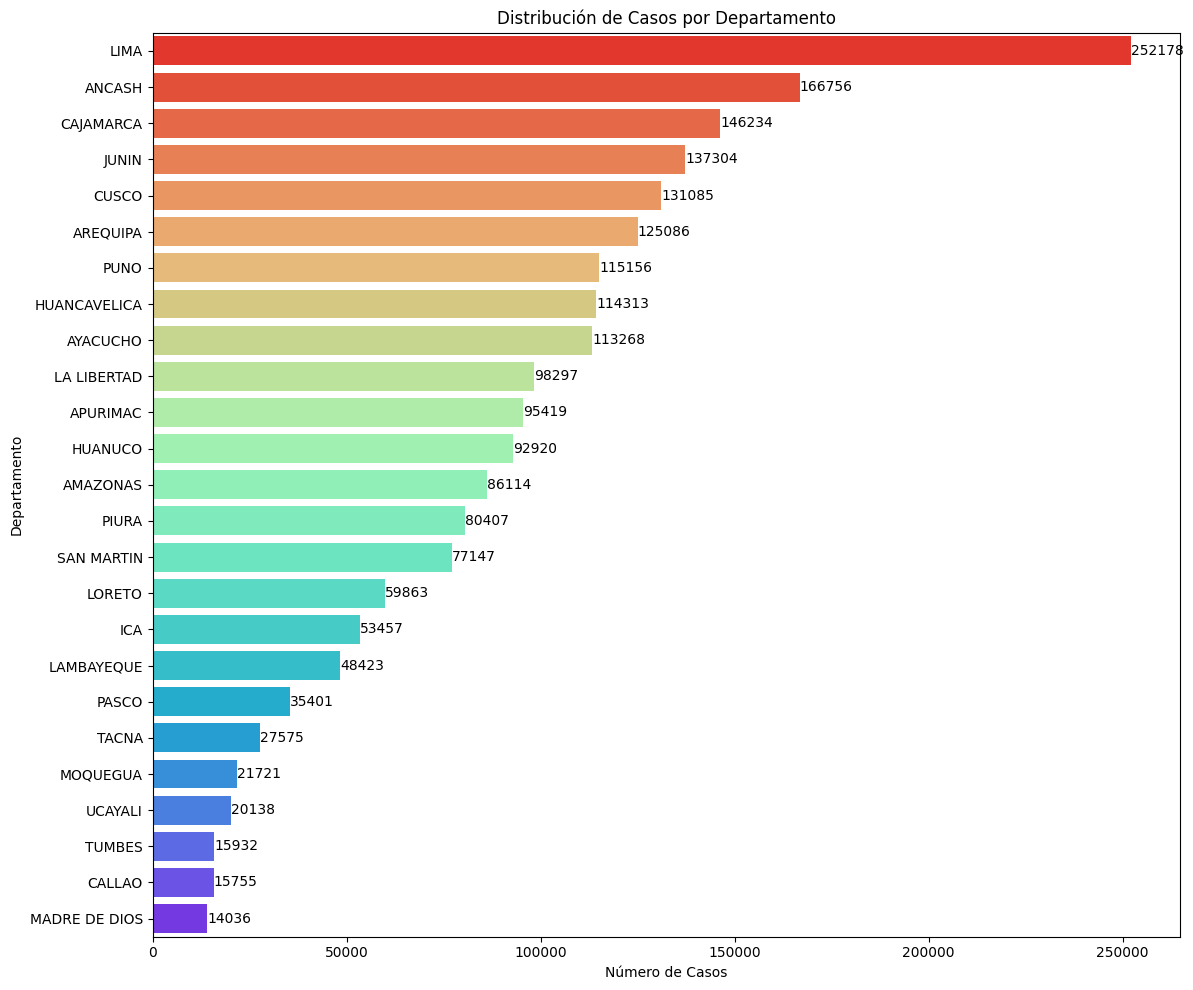

In [ ]:
# Crear el gráfico de barras horizontales
plt.figure(figsize=(12, 10)) # Ajusta el tamaño de la figura, puede necesitar ser más alto para barras horizontales
ax = sns.barplot(x=conteos_departamento.values, y=conteos_departamento.index, palette="rainbow_r") # Intercambia x e y y asigna a una variable 'ax'

plt.title("Distribución de Casos por Departamento") # Añade un título al gráfico
plt.xlabel("Número de Casos") # Etiqueta del eje X (ahora es el conteo)
plt.ylabel("Departamento") # Etiqueta del eje Y (ahora son los departamentos)
# plt.xticks(rotation=90) # No necesitas rotar las etiquetas del eje X con barras horizontales
plt.tight_layout() # Ajusta el diseño

# Añadir la cantidad total sobre cada barra
for i, count in enumerate(conteos_departamento.values):
    ax.text(count + 5, i, str(count), va='center') # count + 5 para un pequeño desplazamiento, i es la posición en el eje y

plt.show() # Muestra el gráfico

### **3.5.2 Análisis de casos IRA en Lima (análisis bivariado)**

Para explorar la relación entre una variable categórica (**Sexo**) y una variable numérica (**Edad**), un gráfico de cajas (boxplot) es una visualización adecuada.

In [ ]:
df_lima = df[df["departamento"] == "LIMA"]

In [ ]:
casos_lima_por_ano = df_lima["ano"].value_counts().sort_index()

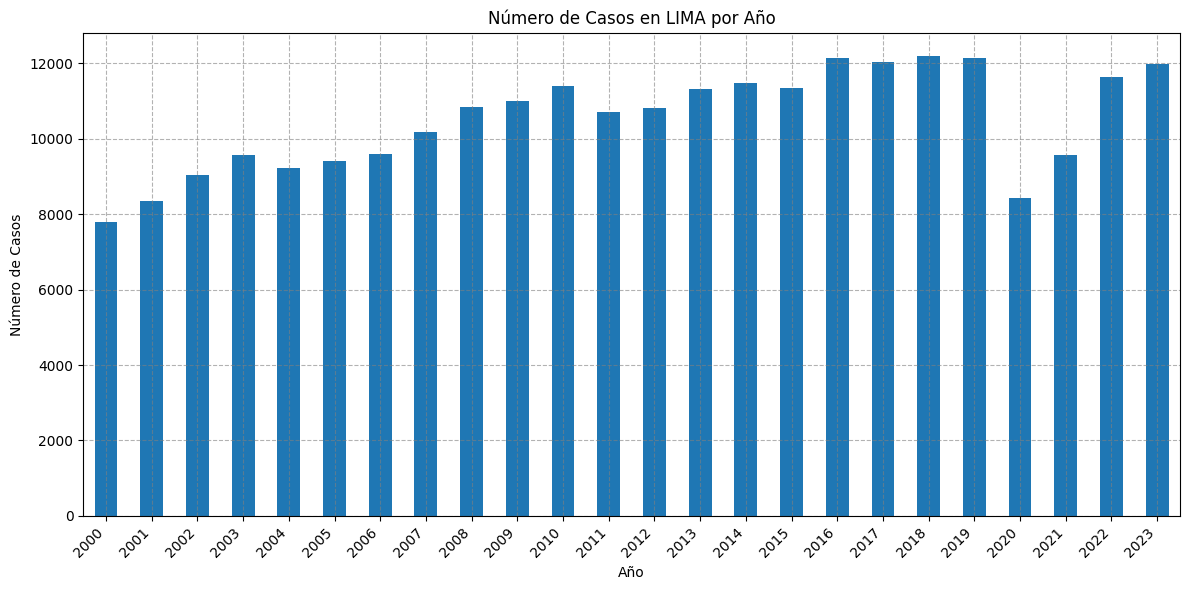

In [ ]:
plt.figure(figsize=(12, 6)) # Adjust figure size as needed
casos_lima_por_ano.plot(kind='bar')
plt.title("Número de Casos en LIMA por Año")
plt.xlabel("Año")
plt.ylabel("Número de Casos")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6, color='gray', which='both')
plt.show()

In [ ]:
casos_neumonias_lima = df_lima.groupby("ano")["neumonias_men5"].sum()
defunciones_lima = df_lima.groupby("ano")["defunciones_men5"].sum()

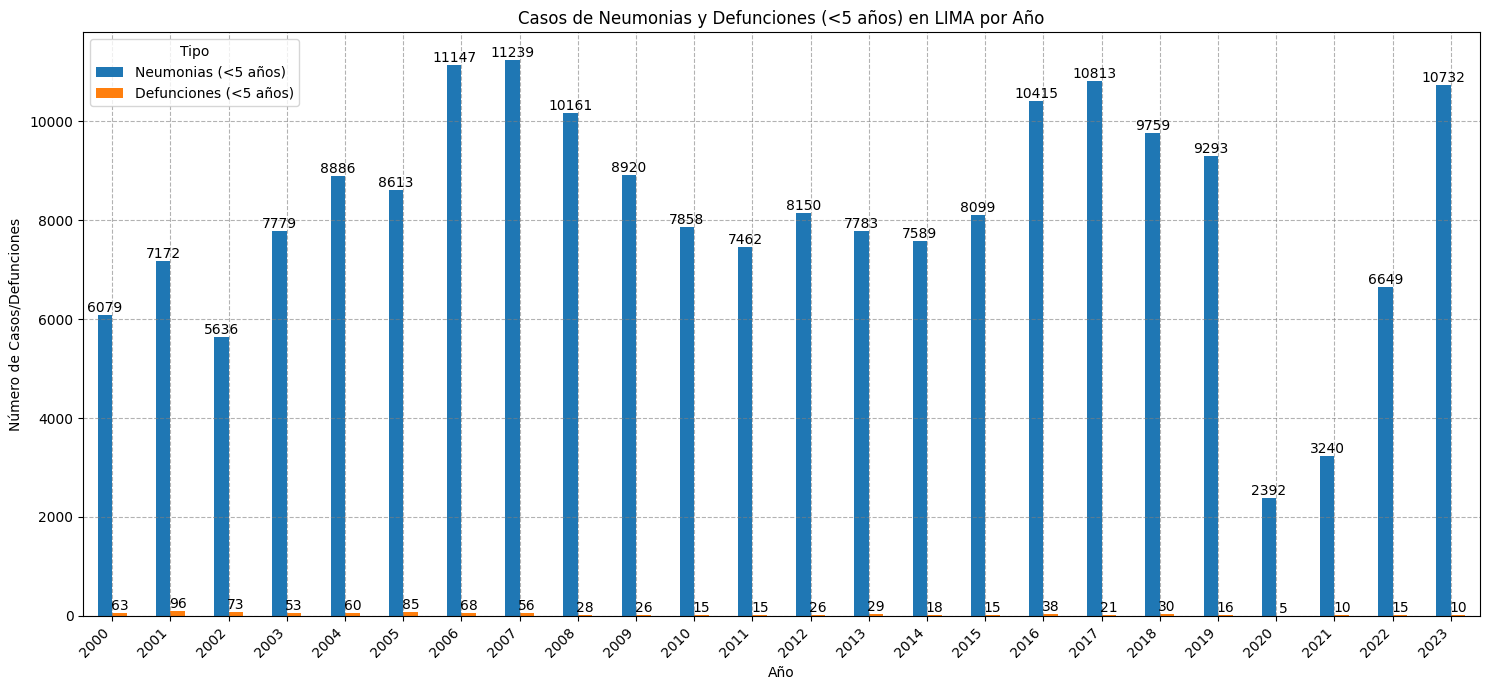

In [ ]:
# Combine the data into a single DataFrame for easier plotting
df_plot = pd.DataFrame({
    'Neumonias (<5 años)': casos_neumonias_lima,
    'Defunciones (<5 años)': defunciones_lima
})

# Create the bar plot
ax = df_plot.plot(kind='bar', figsize=(15, 7))

plt.title("Casos de Neumonias y Defunciones (<5 años) en LIMA por Año")
plt.xlabel("Año")
plt.ylabel("Número de Casos/Defunciones")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.legend(title='Tipo')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6, color='gray', which='both')
# Add the values on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.show()

### **3.5.3 Análisis de Medidas de Tendencia Central y Dispersión**

Vamos a calcular medidas de tendencia central (como la media, mediana y moda) y medidas de dispersión (como la desviación estándar, varianza y rango) para las variables **Sexo, Edad** y **Tipo_Dx**.

In [ ]:
# Análisis para la variable 'neumonia men5' (Cuantitativa)
print("Análisis para la variable 'neumonia men5':")

# Medidas de Tendencia Central para 'neumonia men5'
print(f"  Media: {df_interes['neumonias_men5'].mean():.2f}")
print(f"  Mediana: {df_interes['neumonias_men5'].median():.2f}")
print(f"  Moda: {df_interes['neumonias_men5'].mode()[0]}") # mode() puede devolver múltiples valores si hay un empate
print("\n")

# Medidas de Dispersión para 'neumonia men5'
print(f"  Desviación Estándar: {df_interes['neumonias_men5'].std():.2f}")
print(f"  Varianza: {df_interes['neumonias_men5'].var():.2f}")
print(f"  Rango: {df_interes['neumonias_men5'].max() - df_interes['neumonias_men5'].min()}")
print(f"  Cuartil 1 (Q1): {df_interes['neumonias_men5'].quantile(0.25):.2f}")
print(f"  Cuartil 3 (Q3): {df_interes['neumonias_men5'].quantile(0.75):.2f}")
print(f"  Rango Intercuartílico (IQR): {df_interes['neumonias_men5'].quantile(0.75) - df_interes['neumonias_men5'].quantile(0.25):.2f}")
print("\n" + "="*50 + "\n") # Separador

# Análisis para la variable 'Departamento' (Categórica)
print("Análisis para la variable 'Departamento':")

# Medida de Tendencia Central para 'Departamento' (Moda)
print(f"  Moda: {df_interes['departamento'].mode()[0]}") # La categoría más frecuente
print("\n" + "="*50 + "\n") # Separador

# Análisis para la variable 'neumonia men5' (Categórica)
print("Análisis para la variable 'neumonia men5':")

# Medida de Tendencia Central para 'Tipo_Dx' (Moda)
print(f"  Moda: {df_interes['neumonias_men5'].mode()[0]}") # La categoría más frecuente
print("\n" + "="*50 + "\n") # Separador

Análisis para la variable 'neumonia men5':
  Media: 0.41
  Mediana: 0.00
  Moda: 0


  Desviación Estándar: 1.70
  Varianza: 2.90
  Rango: 155
  Cuartil 1 (Q1): 0.00
  Cuartil 3 (Q3): 0.00
  Rango Intercuartílico (IQR): 0.00


Análisis para la variable 'Departamento':
  Moda: LIMA


Análisis para la variable 'neumonia men5':
  Moda: 0




## **3.6 Estadística inferencial:** prueba de hipótesis

### **3.6.1. Chi-cuadrado**
La prueba de hipótesis no paramétrica **Chi-cuadrado** es una técnica estadística fundamental para analizar datos categóricos, es decir, datos que se pueden agrupar en categorías (com sexo, tipo de enfermedad, opinión, etc.). Se considera **no paramétrica** porque no asume que los datos sigan una distribución de probabilidad específica (como la distribución normal), lo que la hace muy útil en situaciones donde las suposiciones de pruebas paramétricas no se cumplen.

<b>¿Por qué se usa la prueba de Chi-cuadrado?</b>
<ul>
  <li>Se aplica a <b>datos categóricos</b> en forma de tablas de frecuencias.</li>
  <li> Se utiliza para determinar si existe una relación o asociación significativa entre dos variables (<b>prueba de independencia</b>).</li>
  <li> Se usa para comparar una distribución observada con una distribución teórica (<b>prueba de bondad de ajuste</b>).</li>
  <li> Sirve para conocer si la distribución de una variable categórica es la misma en dos o más poblaciones diferentes (<b>prueba de homogeneidad</b>).</li>
</ul>

$ $

**Hipótesis**
* **Hipótesis Nula ($H_{0}$)**: No hay una relación ó asociación entre dos variables categóricas (las variables son independientes).

* **Hipóteisis Alternativa ($H_{1}$)**: Hay una relación ó asociación significativa entre dos variables categóricas.
$ $

**Interpretación**
* Si el valor p (p-value) es **mayor** que el nivel de significancia ($α = 0.05$): No se rechaza **Hipótesis Nula ($H_{0}$)**. Por tanto, no hay evidencia de relación ó asociación entre variables.

* Si el valor p es **menor** que el nivel de significancia: Se rechaza la **Hipóteisis Nula ($H_{0}$)**. Por tanto, Existe evidencia estadística de relación o asociación entre las variables.
$ $

**Consideraciones claves**

* **Tamaño muestral**: Requiere frecuencias esperadas $\geq 5$ en cada celda.
* **Variables categóricas**: No aplica para variables continuas.
* **Direccionalidad**: Chi-Cuadrado solo detecta relación o asociación , **no causalida**.

In [ ]:
tabla = pd.crosstab(df_interes["departamento"], df_interes["neumonias_men5"]).sort_index()
print(tabla)

neumonias_men5     0      1      2     3     4     5     6     7     8    9    \
departamento                                                                    
AMAZONAS         75593   6052   2070   988   531   311   176   129    87   52   
ANCASH          152328   9195   2684  1064   555   338   211   106    82   47   
APURIMAC         85798   5816   1677   692   440   259   191   120    96   58   
AREQUIPA        107598   8698   3483  1749  1008   703   482   334   211  167   
AYACUCHO        105486   4834   1606   585   297   151    96    58    44   41   
CAJAMARCA       125065  11718   4367  1983  1042   556   449   241   177  138   
CALLAO            9595   2262   1130   687   445   328   224   207   187  119   
CUSCO           107931  13187   4866  2142  1082   645   388   268   167  119   
HUANCAVELICA    102502   7596   2270   886   422   251   144    77    68   24   
HUANUCO          72546  10999   4341  1921  1040   615   396   281   213  145   
ICA              45158   510

In [ ]:
df_neumoniaMen3 = df_interes[df_interes["neumonias_men5"]<3]

In [ ]:
nombres_departamentos = ["LIMA","ANCASH","JUNIN","CAJAMARCA"]
df_depA_neumoniaMen3 = df_neumoniaMen3[df_neumoniaMen3["departamento"].isin(nombres_departamentos)]
print(df_depA_neumoniaMen3)

          ano  neumonias_men5  defunciones_men5 departamento  \
86114    2000               2                 0       ANCASH   
86115    2000               2                 0       ANCASH   
86116    2000               2                 0       ANCASH   
86119    2000               1                 0       ANCASH   
86120    2000               0                 0       ANCASH   
...       ...             ...               ...          ...   
1676604  2023               0                 0         LIMA   
1676605  2023               0                 0         LIMA   
1676606  2023               0                 0         LIMA   
1676607  2023               0                 0         LIMA   
1676608  2023               0                 0         LIMA   

         hospitalizados_men5  
86114                      2  
86115                      1  
86116                      2  
86119                      1  
86120                      0  
...                      ...  
1676604       

In [ ]:
tabla_A = pd.crosstab(df_depA_neumoniaMen3["departamento"], df_depA_neumoniaMen3["neumonias_men5"]).sort_index()
print(tabla_A)

neumonias_men5       0      1      2
departamento                        
ANCASH          152328   9195   2684
CAJAMARCA       125065  11718   4367
JUNIN           121593   9465   3052
LIMA            194615  23581  11128


In [ ]:
"""
Aplicar la prueba de Chi-cuadrado de independencia
---------------------------------------------------
  chi2_stat : Esta variable almacena el estadístico Chi-cuadrado

  p_valor         : Esta variable almacena el valor p, que representa la
                    la probabilidad de observar los datos si no ubiera
                    relación entre las variables

  dof             : En esta variable contine los grados de libertar, que
                    es un parámetro relacionado con el tamaño de la muestra
                    y el número de categorias en las variables.

  freq_esperadas  : A esta variable se le asigna las frecuencias esperadas
                    para cada celda de la tabla de contingencia si no hubiera
                    relación entre las variables.
"""

chi2_stat, p_valor, dof, freq_esperadas = stats.chi2_contingency(tabla)

In [ ]:
print("Prueba de Chi-cuadrado de Independencia:")
print(f"Estadístico Chi-cuadrado: {chi2_stat:.3f}")
print(f"Grados de libertad: {dof}")
print(f"p-valor: {p_valor:.3f}\n")

alpha = 0.05 # Nivel de significancia
# Interpretación:
print("\nResultado:")
if p_valor >= alpha:
  print("\tNo se rechaza H0:\n")
  print("\tNo hay una relación ó asociación significativa entre departamento y neumonia men5.\n")
else:
  print("\tSe rechaza H0:\n")
  print("\tHay una relación ó asociación significativa entre departamento y neumonia men5.\n")

Prueba de Chi-cuadrado de Independencia:
Estadístico Chi-cuadrado: 104185.252
Grados de libertad: 2112
p-valor: 0.000


Resultado:
	Se rechaza H0:

	Hay una relación ó asociación significativa entre departamento y neumonia men5.



### **3.6.2. Comparación de medidas:** prueba de hipótesis T-test

La prueba **T-test** (también conocido como **t de Student**) se utiliza para comparar las medias de dos muestras independientes. En este caso, las dos muestras son las edades de los individuos masculinos y femeninos.

**El T-test** es una herramienta fundamental en bioestadística que permite tomar decisiones basadas en evidencia sobre diferencias entre grupos, siendo especialmente valioso en investigación médica y epidemiológica donde las decisiones pueden tener implicaciones importantes para la salud pública.



**Supuestos del T-test**
* Los datos deben seguir una distribución aproximadamente normal (verificar con histogramas o pruebas como **Shapiro-Wilk**).

**Hipótesis**
* **Hipótesis Nula ($H_{0}$)**: No hay una diferencia significativa en la media de la edad entre hombres y mujeres (medias iguales).

* **Hipóteisis Alternativa ($H_{1}$)**: Hay una diferencia significativa en la media de la edad entre hombres y mujeres (medias diferentes).

**Interpretación**

* si **p-valor $\lt \alpha$**, se **rechaza la hipótesis nula ($H_{0}$)**: hay evidencia estadísticamente significativa de una diferencia entre los grupos. Generalmente,  $\alpha = 0.05$, donde $\alpha$ es el nivel de significancia.
* si p-valor $\geq \alpha$, **No** se **rechaza la hipótesis nula** ($H_{0}$): no hay evidencia suficiente para afirmar que las medias son distintas

In [ ]:
# Separar la variable 'Edad' en dos grupos basados en la variable 'Sexo'
neumonias_men5 = df_interes["neumonias_men5"]
defunciones_men5 = df_interes["defunciones_men5"]

print(neumonias_men5)
print(defunciones_men5)

0          0
1          0
2          0
3          3
4          2
          ..
2143980    0
2143981    0
2143982    0
2143983    0
2143984    0
Name: neumonias_men5, Length: 2143985, dtype: int64
0          0
1          0
2          0
3          0
4          0
          ..
2143980    0
2143981    0
2143982    0
2143983    0
2143984    0
Name: defunciones_men5, Length: 2143985, dtype: int64


In [ ]:
# Realizar la prueba T-test independiente
# equal_var=True asume varianzas iguales (T-test estándar).
# Si no estamos seguros de la igualdad de varianzas, podemos usar equal_var=False (Welch's T-test).
t_stat, p_valor_ttest = stats.ttest_ind(neumonias_men5, defunciones_men5, equal_var=True)

print("Prueba T-test Independiente para la Edad entre Sexo Femenino y Masculino:")
print(f"Estadístico T: {t_stat:.3f}")
print(f"p-valor: {p_valor_ttest:.3f}\n")

# Interpretación del p-valor
alpha = 0.05 # Nivel de significancia comúnmente utilizado

print("Interpretación del resultado:")
if p_valor_ttest > alpha:
  print("\tno se rechaza H0.")
  print("\tConcluimos que no existe una diferencia estadísticamente significativa en la media entre\n\tneumonias men5 y defunciones men5.")

else:
  print("\tSe rechaza H0.")
  print("\tConcluimos que existe una diferencia estadísticamente significativa en la media entre\n\tneumonias men5 y defunciones men5.")


Prueba T-test Independiente para la Edad entre Sexo Femenino y Masculino:
Estadístico T: 346.336
p-valor: 0.000

Interpretación del resultado:
	Se rechaza H0.
	Concluimos que existe una diferencia estadísticamente significativa en la media entre
	neumonias men5 y defunciones men5.


In [ ]:
# Opcional: Mostrar las medias de edad para cada grupo
print("\nMedias:")
print(f"\tMedia de neumonias men5: {neumonias_men5.mean():.2f}")
print(f"\tMedia de defunciones men5: {defunciones_men5.mean():.2f}")


Medias:
	Media de neumonias men5: 0.41
	Media de defunciones men5: 0.00


### **3.6.3. Prueba de hipótesis paramétrica Shapiro-Wilk**

La **prueba de Shapiro-Wilk** es un método estadístico utilizado para evaluar si una muestra de datos proviene de una distribución normal. Es una de las pruebas más comunes y poderosas para verificar la normalidad de los datos, lo cual es un supuesto clave en muchas pruebas estadísticas paramétricas, como la t de Student o ANOVA. En investigación, esta prueba es útil para determinar si los datos cumplen con los requisitos de normalidad antes de aplicar métodos estadísticos que asumen una distribución normal.

**Hipótesis para la prueba Shapiro-Wilk**
* **Hipótesis Nula ($H_{0}$)**: Los datos siguen una distribución normal.

* **Hipóteisis Alternativa ($H_{1}$)**: Los datos **No** siguen una distribución normal.

**Interpretación**

* si **p-valor $\leq \alpha$**, se **rechaza la hipótesis nula ($H_{0}$)**: Los datos **no siguen una distribución normal**. Generalmente,  $\alpha = 0.05$, donde $\alpha$ es el nivel de significancia.

* si **p-valor $\gt \alpha$**, no se **rechaza la hipótesis nula** ($H_{0}$): Los datos no difieren de una distribución normal (se asume normalidad).

In [ ]:
# Realizar la prueba de Shapiro-Wilk para el grupo Femenino
shapiro_neumonias_men5, shapiro_neumonias_men5_p = stats.shapiro(neumonias_men5)

print("Prueba de Shapiro-Wilk para neumonias men5:")
print(f"Estadístico Shapiro-Wilk: {shapiro_neumonias_men5:.3f}")
print(f"p-valor: {shapiro_neumonias_men5_p:.3f}\n")

# Interpretación para el grupo Femenino
alfa_shapiro = 0.05
print("Interpretación para el grupo neumonias men5:")
if shapiro_neumonias_men5_p > alfa_shapiro:
  print(f"\tDado que el p-valor ({shapiro_neumonias_men5_p:.3f}) es mayor o igual que el nivel de significancia ({alfa_shapiro}),")
  print("\tno se rechaza H0.")
  print("\tConcluimos que la distribución de neumonias men5 se ajusta a una distribución normal.")

else:
  print(f"\tDado que el p-valor ({shapiro_neumonias_men5_p:.3f}) es menor que el nivel de significancia ({alfa_shapiro}),")
  print("\tse rechaza H0.")
  print("\tConcluimos que la distribución de neumonias men5 no es significativamente normal.")


print("\n" + "="*50 + "\n") # Separador

# Realizar la prueba de Shapiro-Wilk para el grupo Masculino
shapiro_defunciones_men5_stat, shapiro_defunciones_men5_p = stats.shapiro(defunciones_men5)

print("Prueba de Shapiro-Wilk para defunciones men5:")
print(f"Estadístico Shapiro-Wilk: {shapiro_defunciones_men5_stat:.3f}")
print(f"p-valor: {shapiro_defunciones_men5_p:.3f}\n")

# Interpretación para el grupo Masculino
print("Interpretación para el grupo de defunciones men5:")
if shapiro_defunciones_men5_p > alfa_shapiro:
  print(f"\tDado que el p-valor ({shapiro_defunciones_men5_p:.3f}) es mayor o igual que el nivel de significancia ({alfa_shapiro}),")
  print("\tno se rechaza H0.")
  print("\tConcluimos que la distribución de defunciones men5 se ajusta a una distribución normal.")

else:
  print(f"\tDado que el p-valor ({shapiro_defunciones_men5_p:.3f}) es menor que el nivel de significancia ({alfa_shapiro}),")
  print("\tse rechaza H0.")
  print("\tConcluimos que la distribución de defunciones men5 no es significativamente normal.")

print("\n" + "="*50 + "\n") # Separador

Prueba de Shapiro-Wilk para neumonias men5:
Estadístico Shapiro-Wilk: 0.240
p-valor: 0.000

Interpretación para el grupo neumonias men5:
	Dado que el p-valor (0.000) es menor que el nivel de significancia (0.05),
	se rechaza H0.
	Concluimos que la distribución de neumonias men5 no es significativamente normal.


Prueba de Shapiro-Wilk para defunciones men5:
Estadístico Shapiro-Wilk: 0.033
p-valor: 0.000

Interpretación para el grupo de defunciones men5:
	Dado que el p-valor (0.000) es menor que el nivel de significancia (0.05),
	se rechaza H0.
	Concluimos que la distribución de defunciones men5 no es significativamente normal.




/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 2143985.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
# Separar la variable 'Edad' en grupos basados en la variable 'Tipo_Dx'
grupos_tipo_dx = df_interes.groupby("neumonias_men5")
print(grupos_tipo_dx)

In [ ]:
nombre_grupos = grupos_tipo_dx.groups.keys()
print(nombre_grupos)

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 75, 76, 77, 78, 79, 86, 87, 88, 90, 91, 100, 116, 125, 130, 145, 155])


In [ ]:
Dx_C = grupos_tipo_dx.get_group(0)
print(Dx_C)

          ano  neumonias_men5  defunciones_men5 departamento  \
0        2000               0                 0     AMAZONAS   
1        2000               0                 0     AMAZONAS   
2        2000               0                 0     AMAZONAS   
5        2000               0                 0     AMAZONAS   
6        2000               0                 0     AMAZONAS   
...       ...             ...               ...          ...   
2143980  2023               0                 0      UCAYALI   
2143981  2023               0                 0      UCAYALI   
2143982  2023               0                 0      UCAYALI   
2143983  2023               0                 0      UCAYALI   
2143984  2023               0                 0      UCAYALI   

         hospitalizados_men5  
0                          0  
1                          0  
2                          0  
5                          0  
6                          0  
...                      ...  
2143980       

In [ ]:
def pruebaH_shapiroWilk(df, variable, alpha=None):
  shapiro_stat, shapiro_p = stats.shapiro(df[variable])

  print(f"Prueba de Shapiro-Wilk para {variable}:")
  print(f"\tEstadístico Shapiro-Wilk: {shapiro_stat:.3f}")
  print(f"\tp-valor: {shapiro_p:.3f}")

  # Interpretación
  if shapiro_p < alpha:
    print(f"\tSe rechaza H0. La distribución de la Edad en este grupo NO es significativamente normal.")
  else:
    print(f"\tNo se rechaza H0. La distribución de la Edad en este grupo PUEDE ser normal.")

In [ ]:
def pruebaH_jerqueBera(df, variable, alpha):
  jb_test= sm.stats.jarque_bera(df[variable])

  # Interpretación
  print(f"Prueba de Jarque-Bera para {variable}:")
  print(f"\tEstadístico = {jb_test[0]:.4f}, p-valor = {jb_test[1]:.4f}")

  if jb_test[1] < alpha:
    print("\tSe rechaza la hipótesis nula: Los datos NO siguen una distribución normal.\n")

  else:
    print("\tNo se rechaza la hipótesis nula: Los datos siguen una distribución normal.\n")

In [ ]:
pruebaH_shapiroWilk(Dx_C, "neumonias_men5", 0.05)

Prueba de Shapiro-Wilk para neumonias_men5:
	Estadístico Shapiro-Wilk: 1.000
	p-valor: 1.000
	No se rechaza H0. La distribución de la Edad en este grupo PUEDE ser normal.


In [ ]:
pruebaH_jerqueBera(Dx_C, "defunciones_men5", 0.05)

Prueba de Jarque-Bera para defunciones_men5:
	Estadístico = 38957801907426.9141, p-valor = 0.0000
	Se rechaza la hipótesis nula: Los datos NO siguen una distribución normal.



### **3.6.4. Comparación de medidas:** Anova


  La prueba de hipótesis ANOVA (Análisis de la Varianza) es una herramienta estadística paramétrica que se utiliza para comparar las medias de tres o más grupos independientes y determinar si existen diferencias significativas entre ellas. Aunque la ANOVA es relativamente robusta a la falta de la normalidad con tamaños de muestra grandes, la homogeneidad de varianzas es más crítica.

**Nota Importante para ANOVA**

 * **Normalidad**: Las distribuciones de los residuos (o de la variable dependiente dentro de cada grupo) son aproximadamente normales.

 * **Homogeneidad de Varianzas**: Las varianzas de la variable dependiente son aproximadamente iguales en todos los grupos.

 * **Independencia**: Las observaciones son independientes.

Implementar una función para realizar pruebas de hipótesis (distribución normal) Shapiro-Wilk.

Implementar una función para realizar pruebas de hipótesis (distribución normal) Jerque-Bera.

**Hipótesis para la prueba ANOVA**
* **Hipótesis Nula ($H_{0}$)**: Las medias de todos los grupos son iguales.
* **Hipóteisis Alternativa ($H_{1}$)**: Hay al menos un par de grupos cuyas medias de edad son significativamente diferentes.

In [ ]:
# Preparar los datos: asegurar que 'Tipo_Dx' es de tipo category si no lo es,
# ols puede manejar strings, es buena práctica.
df_interes['tipo_neumoniaMen5'] = df_interes['neumonias_men5'].astype('category')
print(df_interes)

          ano  neumonias_men5  defunciones_men5 departamento  \
0        2000               0                 0     AMAZONAS   
1        2000               0                 0     AMAZONAS   
2        2000               0                 0     AMAZONAS   
3        2000               3                 0     AMAZONAS   
4        2000               2                 0     AMAZONAS   
...       ...             ...               ...          ...   
2143980  2023               0                 0      UCAYALI   
2143981  2023               0                 0      UCAYALI   
2143982  2023               0                 0      UCAYALI   
2143983  2023               0                 0      UCAYALI   
2143984  2023               0                 0      UCAYALI   

         hospitalizados_men5 tipo_neumoniaMen5  
0                          0                 0  
1                          0                 0  
2                          0                 0  
3                          0       

In [ ]:
# Realizar la prueba ANOVA usando statsmodels
# La fórmula 'Edad ~ C(Tipo_Dx)' indica que 'Edad' es la variable dependiente
# y 'Tipo_Dx' es la variable independiente categórica (C() asegura que se trate como categórica)
modelo_anova = smf.ols('defunciones_men5 ~ C(tipo_neumoniaMen5)', data=df_interes).fit() # Ajusta el modelo a los datos
tabla_anova = sm.stats.anova_lm(modelo_anova, typ=2) # typ=2 para el tipo de suma de cuadrados

print("Resultado de la Prueba ANOVA (Comparación de Edad entre Tipos de Diagnóstico):")
print(tabla_anova)

Resultado de la Prueba ANOVA (Comparación de Edad entre Tipos de Diagnóstico):
                            sum_sq         df           F  PR(>F)
C(tipo_neumoniaMen5)    338.483903       88.0  683.268251     0.0
Residual              12068.903658  2143896.0         NaN     NaN


In [ ]:
# Interpretación del p-valor de la ANOVA
p_valor_anova = tabla_anova['PR(>F)']['C(tipo_neumoniaMen5)']
alfa_anova = 0.05

print("\nInterpretación del resultado de la ANOVA:")
if p_valor_anova < alfa_anova:
    print(f"\tDado que el p-valor de la ANOVA ({p_valor_anova:.3f}) es menor que el nivel de significancia ({alfa_anova}),")
    print("\n\tSe rechaza la hipótesis nula.")
    print("\tConcluimos que existe una diferencia estadísticamente significativa\n\ten la media de ambos grupos.")
else:
    print(f"\tDado que el p-valor de la ANOVA ({p_valor_anova:.3f}) es mayor o igual que el nivel de significancia ({alfa_anova}),")
    print("\tno se rechaza la hipótesis nula.")
    print("\tConcluimos que no existe una diferencia estadísticamente significativa general en la media de ambos grupos.")


Interpretación del resultado de la ANOVA:
	Dado que el p-valor de la ANOVA (0.000) es menor que el nivel de significancia (0.05),

	Se rechaza la hipótesis nula.
	Concluimos que existe una diferencia estadísticamente significativa
	en la media de ambos grupos.


## **3.7. Modelo Bioestadístico**

### **3.7.1 Regresión logística binaria**

Un modelo de regresión logística es un tipo de modelo estadístico que se utiliza para predecir la probabilidad de que un resultado pertenezca a una de varias categorías. A diferencia de la regresión lineal, que predice un valor continuo, la regresión logística se utiliza para problemas de clasificación.

**¿Para que sirve?**

Sirve para modelar la relación entre una o más **variables independientes** (predictoras) y una **variable dependiente categórica** (la que queremos predecir). La variable dependiente suele ser binaria (con dos categorías, como sí/no, verdadero/falso, 0/1).

Se va ha implementar el modelo de regresión logística con la relación matemática `"hubo_defuncion ~ neumonias_men5 + C(hospitalizados_men5)"`. Esto significa que las variables predictoras son **edad** (cuantitativa) y **sexo** (categórica).

La expresión matemática estimada para este modelo está representada por la ecuación {eq}`eq:rlb_ira`:

$$
P(Defunción|D=1) = \frac{1}{1 + e^{-(\beta_{0} + \beta_{1}\times x_{1} + \beta_{2}\times x_{2})}} \hspace{2cm}
$$(eq:rlb_ira)

Donde:

* $\beta_0$ es el **coeficiente estimado del intercepto** obtenido de la salida del modelo `modelo_logistico.params["Intercep"]`.

* $\beta_1$ e el **coeficiente estimado para la variable edad** (`modelo_logistico.params["neumonias_men5"]`).

* $\beta_2$ es el **coeficiente estimado para la variable sexo** (`modelo_logistico.params["hospitalizados_men5"]`)

* $x_{1}$ y $x_{2}$ representan  las variables `neumonias_men5` y `hospitalizados_men5`, respectivamente.



$ $

**Referencias**
> <a href="https://link.springer.com/article/10.1186/s12889-024-18338-8">Lyu, Y., Xu, Q., & Liu, J. (2024). Exploring the medical decision-making patterns and influencing factors among the general Chinese public: a binary logistic regression analysis. BMC public health, 24(1), 887.</a>

> <a href="https://www.nature.com/articles/s41598-023-49872-x">Talin, I. A., Abid, M. H., Samad, M. A., Domínguez Azpíroz, I., de la Torre Diez, I., Ashraf, I., & Nahid, A. A. (2023). Exploring factors influencing the severity of pregnancy anemia in India: a study using proportional odds model. Scientific Reports, 13(1), 22816.</a>

> <a href="https://sjuoz.uoz.edu.krd/index.php/sjuoz/article/view/442">Abdulqader, Q. M. (2017). Applying the binary logistic regression analysis on the medical data. Science Journal of University of Zakho, 5(4), 330-334.</a>

> <a href="https://pmc.ncbi.nlm.nih.gov/articles/PMC4419893/">Avali, V. R., Cooper, G. F., & Gopalakrishnan, V. (2014, November). Application of Bayesian logistic regression to mining biomedical data. In AMIA Annual Symposium Proceedings (Vol. 2014, p. 266)</a>


In [ ]:
df_model = df_interes[["neumonias_men5", "defunciones_men5", "hospitalizados_men5"]]
print(df_model)

         neumonias_men5  defunciones_men5  hospitalizados_men5
0                     0                 0                    0
1                     0                 0                    0
2                     0                 0                    0
3                     3                 0                    0
4                     2                 0                    0
...                 ...               ...                  ...
2143980               0                 0                    0
2143981               0                 0                    0
2143982               0                 0                    0
2143983               0                 0                    0
2143984               0                 0                    0

[2143985 rows x 3 columns]


In [ ]:
df_interes=df_interes[df_interes["neumonias_men5"]<5]

In [ ]:
# Crear una variable dependiente binaria de ejemplo: ¿Hubo defunciones?
# Asumimos que un valor > 0 en 'defunciones_men5' significa 'hubo defunción'
df_interes['hubo_defuncion'] = (df_interes['defunciones_men5'] > 0).astype(int)

# Verificamos la distribución de la nueva variable binaria
print("Distribución de la variable 'hubo_defuncion':")
print(df_interes['hubo_defuncion'].value_counts())
print("\n" + "="*50 + "\n")

Distribución de la variable 'hubo_defuncion':
hubo_defuncion
0    2093071
1       6850
Name: count, dtype: int64




<ipython-input-52-942279726>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_interes['hubo_defuncion'] = (df_interes['defunciones_men5'] > 0).astype(int)


Empleando las variables de `df_model` como predictores y la variable binaria `(hubo_defuncion)` como varaible dependiente.

In [ ]:
# Definir la fórmula del modelo de regresión logística
# La fórmula es 'variable_dependiente ~ predictor1 + predictor2 + ...'
# Usaremos 'hubo_defuncion' como variable dependiente y las columnas de df_model como predictores
formula = 'hubo_defuncion ~ neumonias_men5 + hospitalizados_men5'

# Ajustar el modelo de regresión logística utilizando statsmodels
# smf.logit se utiliza para modelos logísticos binarios
modelo_logistico = smf.logit(formula, data=df_interes).fit()

# Imprimir el resumen del modelo
print("Resumen del Modelo de Regresión Logística Binaria:")
print(modelo_logistico.summary())

Optimization terminated successfully.
         Current function value: 0.019026
         Iterations 10
Resumen del Modelo de Regresión Logística Binaria:
                           Logit Regression Results                           
Dep. Variable:         hubo_defuncion   No. Observations:              2099921
Model:                          Logit   Df Residuals:                  2099918
Method:                           MLE   Df Model:                            2
Date:                Tue, 17 Jun 2025   Pseudo R-squ.:                  0.1325
Time:                        22:03:02   Log-Likelihood:                -39953.
converged:                       True   LL-Null:                       -46058.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -6.4332      0.

In [ ]:
print(modelo_logistico.params["hospitalizados_men5"])

0.13769974754178668


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


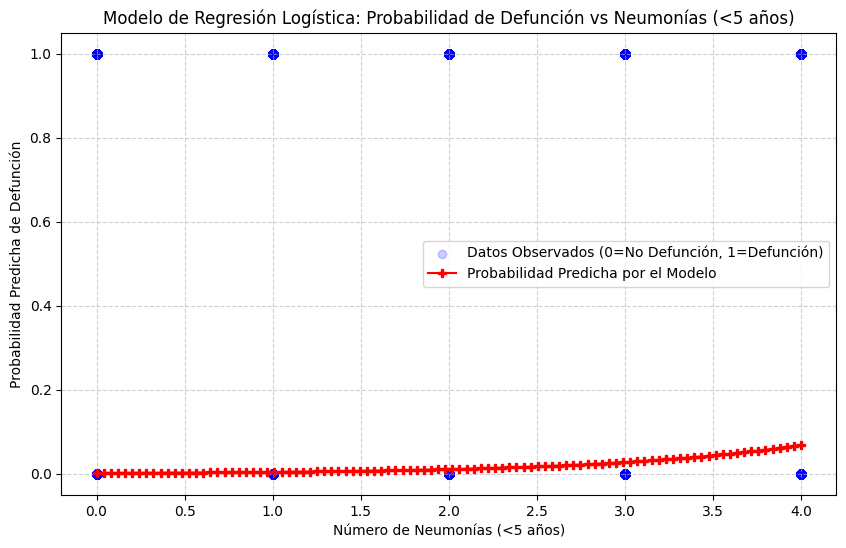

In [ ]:
# --- Graficar el modelo logístico ---

# 1. Preparar datos para la predicción
# Vamos a predecir la probabilidad en un rango de valores de 'neumonias_men5'
# Mantenemos los otros predictores en sus valores promedio
min_neumonias = df_interes['neumonias_men5'].min()
max_neumonias = df_interes['neumonias_men5'].max()

# Crear un rango de valores para 'neumonias_men5'
rango_neumonias = np.linspace(min_neumonias, max_neumonias, 100)

# Crear un DataFrame para hacer predicciones
# Mantener 'defunciones_men5' y 'hospitalizados_men5' en sus medias para la predicción
data_para_predecir = pd.DataFrame({
    'neumonias_men5': rango_neumonias,
    'defunciones_men5': df_interes['defunciones_men5'].mean(), # Mantener en la media
    'hospitalizados_men5': df_interes['hospitalizados_men5'].mean() # Mantener en la media
})

# 2. Predecir las probabilidades usando el modelo ajustado
# El método 'predict' devuelve las probabilidades
probabilidades_predichas = modelo_logistico.predict(data_para_predecir)

# 3. Graficar
plt.figure(figsize=(10, 6))

# Graficar los datos observados (añadimos un pequeño jitter para visualizarlos mejor)
# El jitter es un desplazamiento aleatorio pequeño para que los puntos superpuestos sean visibles
plt.scatter(df_interes['neumonias_men5'], df_interes['hubo_defuncion'], color='blue', label='Datos Observados (0=No Defunción, 1=Defunción)', alpha=0.2)

# Graficar la curva de probabilidad predicha por el modelo
plt.plot(rango_neumonias, probabilidades_predichas, color='red', marker='P', label='Probabilidad Predicha por el Modelo')

# Configurar el gráfico
plt.title('Modelo de Regresión Logística: Probabilidad de Defunción vs Neumonías (<5 años)')
plt.xlabel('Número de Neumonías (<5 años)')
plt.ylabel('Probabilidad Predicha de Defunción')
plt.ylim(-0.05, 1.05) # Limitar el eje Y entre 0 y 1 para probabilidades
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

#**IV. Referencias**



###**4.1 Libros y manuales**

- Libro de estadisitica con python

  https://www.editorial-sciela.org/index.php/sciela/article/view/16/49

- Introducción a la teoria de probabilidades

  https://ciladi.org/wp-content/uploads/Version_final_Introduccion-Probabilidad-Python-vf_Bayas-3.pdf

- Guía practica de análsis exploratorio de python

  https://datos.gob.es/sites/default/files/doc/file/guia_eda_python.pdf


**Cursos en linea**

- Estadística W3School:

  https://www.w3schools.com/statistics/index.php

- Estadística con python:

  https://docs.python.org/es/3/library/statistics.html

- Kaggle:

  https://www.kaggle.com/code/saurav9786/statistics-for-data-scientists

**Aplicaciones IA**

- Gemini iA

  https://gemini.google.com

- DeepSeek

  https://www.deepseek.com/

- Chat GPT

  https://chatgpt.com/

- Claude IA

  https://claude.ai/

- Julius IA:

  https://julius.ai

